In [97]:
!pip install optuna

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import KFold

import optuna

In [99]:
def mean_wrinkler_score(y_true, y_pred_lo, y_pred_hi, alpha=0.2):
  scores = np.full(len(y_true), y_pred_hi - y_pred_lo)
  mask_lo = y_true < y_pred_lo
  scores[mask_lo] += (y_pred_lo[mask_lo] - y_true[mask_lo]) * (2/alpha)
  mask_hi = y_true > y_pred_hi
  scores[mask_hi] += (y_true[mask_hi] - y_pred_hi[mask_hi]) * (2/alpha)

  return np.mean(scores)

In [100]:
honey = pd.read_csv('honey.csv', sep=";")
weather = pd.read_csv('df_weekly_2019_2025.csv')
beehives = pd.read_csv('ule.csv', sep=";")

In [101]:
honey.head()

,year,week,honey,harvest
0,2019,30,66.0,1
1,2019,32,55.0,1
2,2019,33,134.0,2
3,2019,34,72.0,1
4,2019,35,59.0,1


In [102]:
beehives.head()

,year,beehive
0,2019,92
1,2020,86
2,2021,98
3,2022,100
4,2023,87


In [103]:
weather.head()

,year,week,temp,wspd,prcp,pres
0,2019,18,8.644572,2.952617,0.247276,940.72546
1,2019,19,8.801729,2.939627,0.163314,946.07404
2,2019,20,10.284056,2.588411,0.200703,949.08860
3,2019,21,13.292661,2.689059,0.371334,943.73720
4,2019,22,14.097325,2.743598,0.164248,950.88153


In [104]:
df = pd.merge(honey, weather, on=["year", "week"], how="inner")

In [105]:
df = pd.merge(df, beehives, on="year", how="inner")

In [106]:
weather_filtered = weather[(weather['week'] >= 18) & (weather['week'] <= 30)]

weather_filtered['feature_week'] = weather_filtered['week'].astype(str) + '_'
weather_pivot = weather_filtered.pivot_table(
    index='year',
    columns='feature_week',
    values=['temp', 'wspd', 'prcp', 'pres']
)

weather_pivot.columns = [f'{col[0]}_{col[1].replace("_", "")}' for col in weather_pivot.columns]

df = pd.merge(df, weather_pivot, on='year', how='left')
df.head()

/tmp/ipykernel_64989/65519405.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather_filtered['feature_week'] = weather_filtered['week'].astype(str) + '_'


,year,week,honey,harvest,temp,wspd,prcp,pres,beehive,prcp_18,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,18.468962,2.068542,0.125877,949.43176,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,19.387705,1.972191,0.171244,948.63810,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,16.821316,1.924085,0.108202,949.98334,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,18.534908,1.906017,0.032221,957.32385,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,20.576923,1.698392,0.071077,954.63135,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [107]:
df.columns

Index(['year', 'week', 'honey', 'harvest', 'temp', 'wspd', 'prcp', 'pres',
       'beehive', 'prcp_18', 'prcp_19', 'prcp_20', 'prcp_21', 'prcp_22',
       'prcp_23', 'prcp_24', 'prcp_25', 'prcp_26', 'prcp_27', 'prcp_28',
       'prcp_29', 'prcp_30', 'pres_18', 'pres_19', 'pres_20', 'pres_21',
       'pres_22', 'pres_23', 'pres_24', 'pres_25', 'pres_26', 'pres_27',
       'pres_28', 'pres_29', 'pres_30', 'temp_18', 'temp_19', 'temp_20',
       'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25', 'temp_26',
       'temp_27', 'temp_28', 'temp_29', 'temp_30', 'wspd_18', 'wspd_19',
       'wspd_20', 'wspd_21', 'wspd_22', 'wspd_23', 'wspd_24', 'wspd_25',
       'wspd_26', 'wspd_27', 'wspd_28', 'wspd_29', 'wspd_30'],
      dtype='object')

In [108]:
df.head()

,year,week,honey,harvest,temp,wspd,prcp,pres,beehive,prcp_18,...,wspd_21,wspd_22,wspd_23,wspd_24,wspd_25,wspd_26,wspd_27,wspd_28,wspd_29,wspd_30
0,2019,30,66.0,1,18.468962,2.068542,0.125877,949.43176,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
1,2019,32,55.0,1,19.387705,1.972191,0.171244,948.63810,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
2,2019,33,134.0,2,16.821316,1.924085,0.108202,949.98334,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
3,2019,34,72.0,1,18.534908,1.906017,0.032221,957.32385,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542
4,2019,35,59.0,1,20.576923,1.698392,0.071077,954.63135,92,0.247276,...,2.689059,2.743598,2.138825,2.461001,1.871986,2.66471,2.515738,2.560595,2.082703,2.068542


In [109]:
train = df[df["year"] <= 2023]
test = df[df["year"] >= 2024]

In [110]:
# features = ["temp", "wspd", "prcp", "pres", "beehive", "harvest"]

In [111]:
features = [col for col in df.columns if col != 'honey']
print(features)

['year', 'week', 'harvest', 'temp', 'wspd', 'prcp', 'pres', 'beehive', 'prcp_18', 'prcp_19', 'prcp_20', 'prcp_21', 'prcp_22', 'prcp_23', 'prcp_24', 'prcp_25', 'prcp_26', 'prcp_27', 'prcp_28', 'prcp_29', 'prcp_30', 'pres_18', 'pres_19', 'pres_20', 'pres_21', 'pres_22', 'pres_23', 'pres_24', 'pres_25', 'pres_26', 'pres_27', 'pres_28', 'pres_29', 'pres_30', 'temp_18', 'temp_19', 'temp_20', 'temp_21', 'temp_22', 'temp_23', 'temp_24', 'temp_25', 'temp_26', 'temp_27', 'temp_28', 'temp_29', 'temp_30', 'wspd_18', 'wspd_19', 'wspd_20', 'wspd_21', 'wspd_22', 'wspd_23', 'wspd_24', 'wspd_25', 'wspd_26', 'wspd_27', 'wspd_28', 'wspd_29', 'wspd_30']


In [112]:
X_train = train[features]
y_train = train["honey"]

X_test = test[features]
y_test = test["honey"]

In [113]:
# najlepszy
model = Ridge(
    alpha=10.0
)

In [114]:
# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42
# )

In [115]:
model.fit(X_train, y_train)

Ridge(alpha=10.0)

In [116]:
y_pred = model.predict(X_test)

In [117]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 27.357990223933875
RMSE: 35.53604986967676


In [118]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]])

    year  week  honey  predicted_honey
33  2024    27  126.7       113.548847
34  2024    28   45.5        74.433521
35  2024    30  134.4       120.865821
36  2024    31   72.8       128.709522
37  2024    32  105.0       129.730574
38  2024    33   65.8        98.796326
39  2024    34  100.1       125.308884
40  2024    35   53.9       136.364518
41  2024    37  148.4       152.117220
42  2025    28  126.7       120.643196
43  2025    31  191.1       189.740373
44  2025    33   42.0       101.012220
45  2025    35  109.9       132.528040
46  2025    36  217.0       203.690725


In [119]:
real_test_honey = sum(test["honey"])
predicted_honey_sum = sum(results["predicted_honey"])
print(predicted_honey_sum - real_test_honey)

288.18978832560447


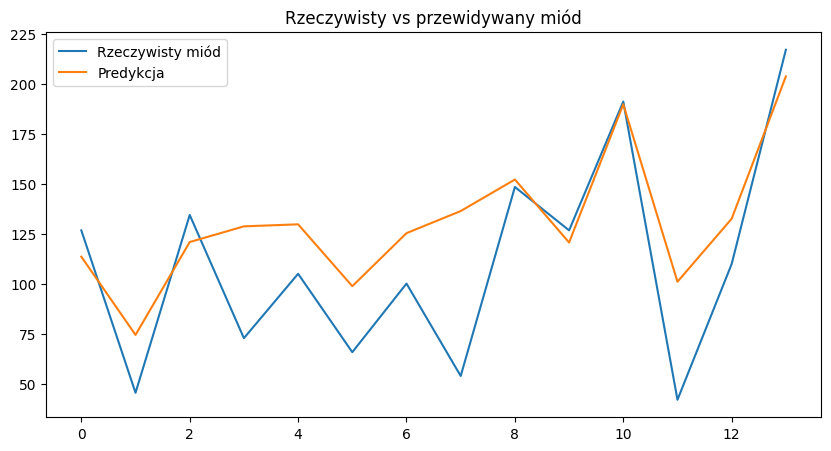

In [120]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [121]:
# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#         'max_depth': trial.suggest_int('max_depth', 2, 10),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
#         'subsample': trial.suggest_float('subsample', 0.5, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'gamma': trial.suggest_float('gamma', 0.0, 0.5),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#         'objective': 'reg:squarederror',
#         'random_state': 42
#     }

#     kf = KFold(n_splits=10, shuffle=True, random_state=42)
#     mae_scores = []

#     for train_index, val_index in kf.split(X_train, y_train):
#         X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
#         y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

#         model = XGBRegressor(**params)
#         model.fit(X_train_fold, y_train_fold)
#         preds = model.predict(X_val_fold)
#         mae = mean_absolute_error(y_val_fold, preds)
#         mae_scores.append(mae)

#     return np.mean(mae_scores)

# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=400)

# print("Number of finished trials: ", len(study.trials))
# print("Best trial:")
# trial = study.best_trial

# print("  Value: {}".format(trial.value))
# print("  Params: ")
# for key, value in trial.params.items():
#     print("    {}: {}".format(key, value))

In [122]:
model = XGBRegressor(
    n_estimators = 535,
    max_depth = 2,
    learning_rate = 0.2921792932332326,
    subsample = 0.9155337675817755,
    colsample_bytree = 0.8845054280373575,
    gamma = 0.3765311627058617,
    min_child_weight = 4,
    reg_alpha = 0.0017374350645646623,
    reg_lambda = 1.7116226997682449
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8845054280373575, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.3765311627058617, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2921792932332326,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=4, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=535, n_jobs=None,
             num_parallel_tree=None, ...)

In [123]:
# model = XGBRegressor(
#     n_estimators = 246,
#     max_depth = 2,
#     learning_rate = 0.011133650506553542,
#     subsample = 0.9473110238449685,
#     colsample_bytree = 0.9736095478543997,
#     gamma = 0.08740556580122627,
#     min_child_weight = 6,
#     reg_alpha = 0.0016821754165382188,
#     reg_lambda = 0.0016821754165382188
# )

# model.fit(X_train, y_train)


In [124]:
y_pred = model.predict(X_test)

In [125]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 29.270747756958006
RMSE: 38.14777026675047


In [126]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]].head())

    year  week  honey  predicted_honey
33  2024    27  126.7        88.451996
34  2024    28   45.5       140.710175
35  2024    30  134.4        84.482536
36  2024    31   72.8        81.643845
37  2024    32  105.0       153.756104


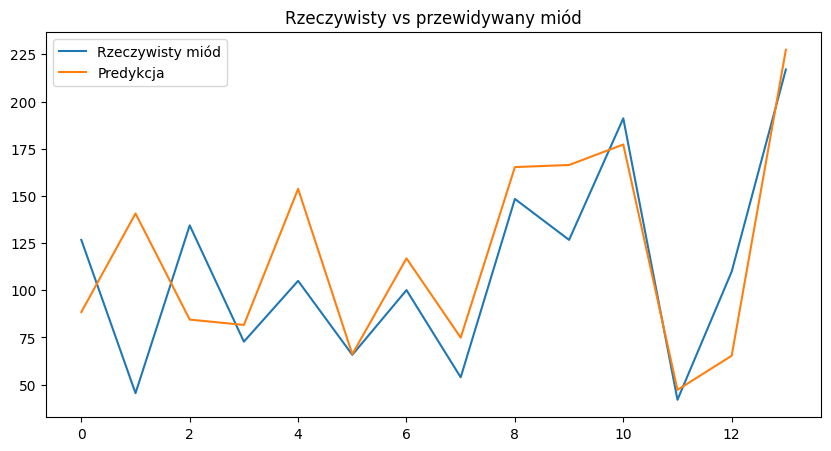

In [127]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [128]:
real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
predicted_honey_sum_2024 = results.loc[results["year"] == 2024, "predicted_honey"].sum()

print(predicted_honey_sum_2024 - real_test_honey_2024)

119.69455566406248


In [129]:
real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()
predicted_honey_sum_2025 = results.loc[results["year"] == 2025, "predicted_honey"].sum()

print(predicted_honey_sum_2025 - real_test_honey_2025)

-3.0881835937500455


In [130]:
real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()

In [131]:
prc_2024 = (predicted_honey_sum_2024 - real_test_honey_2024) / real_test_honey_2024 * 100
prc_2025 = (predicted_honey_sum_2025 - real_test_honey_2025) / real_test_honey_2025 * 100

In [132]:
print(f"2024: {prc_2024}, 2025: {prc_2025}")

2024: 14.03877031011758, 2025: -0.4497136440585474


In [133]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mae_scores = []
rmse_scores = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    cv_model = XGBRegressor(
        n_estimators=535,
        max_depth=2,
        learning_rate=0.2921792932332326,
        subsample=0.9155337675817755,
        colsample_bytree=0.8845054280373575,
        gamma=0.3765311627058617,
        min_child_weight=4,
        reg_alpha=0.0017374350645646623,
        reg_lambda=1.7116226997682449
    )

    cv_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = cv_model.predict(X_val_fold)

    fold_mae = mean_absolute_error(y_val_fold, y_pred_fold)
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))

    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)

    print(f"Fold {fold + 1} - MAE: {fold_mae:.2f}, RMSE: {fold_rmse:.2f}")

print("\nAverage MAE:", np.mean(mae_scores))
print("Average RMSE:", np.mean(rmse_scores))

Fold 1 - MAE: 60.56, RMSE: 73.69
Fold 2 - MAE: 46.15, RMSE: 61.61
Fold 3 - MAE: 29.60, RMSE: 33.13
Fold 4 - MAE: 67.10, RMSE: 74.83
Fold 5 - MAE: 35.46, RMSE: 43.11
Fold 6 - MAE: 84.37, RMSE: 86.91
Fold 7 - MAE: 33.21, RMSE: 42.09
Fold 8 - MAE: 80.94, RMSE: 98.75
Fold 9 - MAE: 47.01, RMSE: 58.00
Fold 10 - MAE: 101.03, RMSE: 115.04

Average MAE: 58.542499732971194
Average RMSE: 68.71570620096124


In [134]:
corr = df.corr()
honey_corr = corr["honey"].sort_values(ascending=False)

honey_corr

,honey
honey,1.000000
harvest,0.526461
prcp,0.409763
wspd,0.380275
prcp_26,0.311182
...,...
temp_23,-0.246829
temp_21,-0.252554
wspd_27,-0.268982
temp_22,-0.290444


In [135]:
train = df[df["year"] <= 2022]
test = df[df["year"] >= 2023]

In [136]:
X_train = train[features]
y_train = train["honey"]

X_test = test[features]
y_test = test["honey"]

In [137]:
model = XGBRegressor(
    n_estimators = 535,
    max_depth = 2,
    learning_rate = 0.2921792932332326,
    subsample = 0.9155337675817755,
    colsample_bytree = 0.8845054280373575,
    gamma = 0.3765311627058617,
    min_child_weight = 4,
    reg_alpha = 0.0017374350645646623,
    reg_lambda = 1.7116226997682449
)

model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8845054280373575, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=0.3765311627058617, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.2921792932332326,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=2, max_leaves=None,
             min_child_weight=4, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=535, n_jobs=None,
             num_parallel_tree=None, ...)

In [138]:
# model = XGBRegressor(
#     n_estimators = 246,
#     max_depth = 2,
#     learning_rate = 0.011133650506553542,
#     subsample = 0.9473110238449685,
#     colsample_bytree = 0.9736095478543997,
#     gamma = 0.08740556580122627,
#     min_child_weight = 6,
#     reg_alpha = 0.0016821754165382188,
#     reg_lambda = 0.0016821754165382188
# )

# model.fit(X_train, y_train)

In [139]:
y_pred = model.predict(X_test)

In [140]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 36.66369743347168
RMSE: 44.94112753748846


In [141]:
results = test.copy()
results["predicted_honey"] = y_pred

print(results[["year", "week", "honey", "predicted_honey"]].head())

    year  week  honey  predicted_honey
29  2023    26  131.6       223.313904
30  2023    27  159.6       157.064514
31  2023    33   81.9        50.030785
32  2023    35  171.5       234.683578
33  2024    27  126.7       100.978043


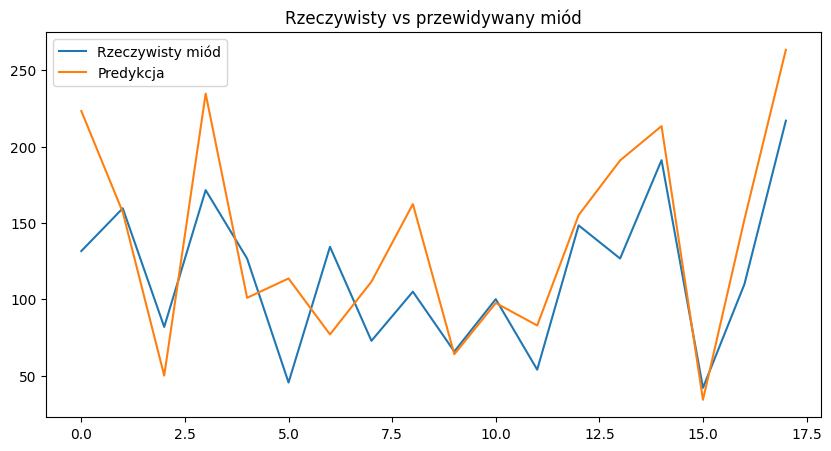

In [142]:
plt.figure(figsize=(10,5))
plt.plot(results["honey"].values, label="Rzeczywisty miód")
plt.plot(results["predicted_honey"].values, label="Predykcja")
plt.legend()
plt.title("Rzeczywisty vs przewidywany miód")
plt.show()

In [143]:
real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
predicted_honey_sum_2024 = results.loc[results["year"] == 2024, "predicted_honey"].sum()

real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()
predicted_honey_sum_2025 = results.loc[results["year"] == 2025, "predicted_honey"].sum()

real_test_honey_2023 = test.loc[test["year"] == 2023, "honey"].sum()
predicted_honey_sum_2023 = results.loc[results["year"] == 2023, "predicted_honey"].sum()

real_test_honey_2024 = test.loc[test["year"] == 2024, "honey"].sum()
real_test_honey_2025 = test.loc[test["year"] == 2025, "honey"].sum()
real_test_honey_2023 = test.loc[test["year"] == 2023, "honey"].sum()

prc_2024 = (predicted_honey_sum_2024 - real_test_honey_2024) / real_test_honey_2024 * 100
prc_2025 = (predicted_honey_sum_2025 - real_test_honey_2025) / real_test_honey_2025 * 100
prc_2023 = (predicted_honey_sum_2023 - real_test_honey_2023) / real_test_honey_2023 * 100

print(f"2023: {prc_2023}, 2024: {prc_2024}, 2025: {prc_2025}")

2023: 22.12500430361733, 2024: 13.20109393097217, 2025: 24.413193235651477


In [144]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mae_scores = []
rmse_scores = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):

    X_train_fold = X_train.iloc[train_index]
    X_val_fold = X_train.iloc[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold = y_train.iloc[val_index]

    cv_model = XGBRegressor(
      n_estimators = 535,
      max_depth = 2,
      learning_rate = 0.2921792932332326,
      subsample = 0.9155337675817755,
      colsample_bytree = 0.8845054280373575,
      gamma = 0.3765311627058617,
      min_child_weight = 4,
      reg_alpha = 0.0017374350645646623,
      reg_lambda = 1.7116226997682449
    )

    cv_model.fit(X_train_fold, y_train_fold)

    y_pred_fold = cv_model.predict(X_val_fold)

    fold_mae = mean_absolute_error(y_val_fold, y_pred_fold)
    fold_rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred_fold))

    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)

    print(f"Fold {fold + 1} - MAE: {fold_mae:.2f}, RMSE: {fold_rmse:.2f}")

print("\nAverage MAE:", np.mean(mae_scores))
print("Average RMSE:", np.mean(rmse_scores))

Fold 1 - MAE: 86.94, RMSE: 89.77
Fold 2 - MAE: 24.75, RMSE: 38.80
Fold 3 - MAE: 93.14, RMSE: 125.83
Fold 4 - MAE: 110.68, RMSE: 126.30
Fold 5 - MAE: 60.94, RMSE: 85.69
Fold 6 - MAE: 29.17, RMSE: 36.41
Fold 7 - MAE: 19.16, RMSE: 29.44
Fold 8 - MAE: 104.38, RMSE: 105.39
Fold 9 - MAE: 92.09, RMSE: 103.98
Fold 10 - MAE: 157.97, RMSE: 169.30

Average MAE: 77.92267767588297
Average RMSE: 91.09039152454253
